In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [ ]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad, MAE_grad
from model.utils import *
from model.linear_model import LinearModel
import matplotlib.pyplot as plt
import os
os.makedirs("figures/q1", exist_ok=True)

---
# Question 1: Linear Regression
---

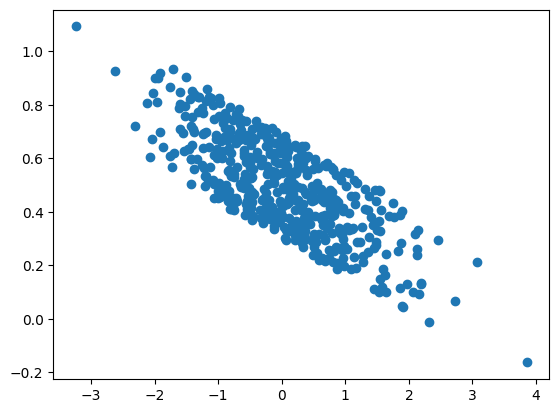

In [4]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

---
## Q1(a) — Plot Loss Curves for Learning Rate ∈ {0.1, 0.01, 0.001}
Applied to all datasets: linear_data_A, B, C, D
---

In [ ]:
# Q1(a): Plot loss curves for lr in {0.1, 0.01, 0.001} - all datasets
import os
os.makedirs("figures/q1", exist_ok=True)

seed = 42
np.random.seed(seed)

datasets = {}
dataset_names = ['A', 'B', 'C', 'D']
lrs = [0.1, 0.01, 0.001]

for name in dataset_names:
    data = np.load(f'data/linear_data/linear_data_{name}.npz')
    datasets[name] = (data['X_data'], data['y_data'])

for name, (X, y) in datasets.items():
    for lr in lrs:
        np.random.seed(seed)
        model = LinearModel(dim=X.shape[1], is_reg=True, loss_fn=MSE, grad_fn=MSE_grad)
        lr_str = str(lr).replace('.', '_')
        model.fit(X, y, lr=lr, n_iteration=500, val_ratio=0.2, title=None)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.set_title(f'Q1(a) Loss Curve - Dataset {name} | lr={lr}')
        ax.set_xlabel('Iterations')
        ax.set_ylabel('Loss')
        ax.plot(model.train_losses, 'o-', color='r', label='Training loss', markersize=1)
        ax.plot(model.val_losses, 'o-', color='g', label='Validation loss', markersize=1)
        ax.legend(loc='best')
        plt.tight_layout()
        plt.savefig(f'figures/q1/loss_curve_dataset_{name}_lr_{lr_str}.png', dpi=100)
        plt.show()
        plt.close()

---
## Q1(b) — Evaluation using evaluate_linear_regression()
Metrics: MSE, MAE, RMSE, R-squared | All datasets × All learning rates
---

In [ ]:
# Q1(b): Evaluate using evaluate_linear_regression - all datasets x all lr
for name, (X, y) in datasets.items():
    print(f"\n=== Dataset {name} ===")
    for lr in lrs:
        np.random.seed(seed)
        model = LinearModel(dim=X.shape[1], is_reg=True, loss_fn=MSE, grad_fn=MSE_grad)
        model.fit(X, y, lr=lr, n_iteration=500, val_ratio=0.2, title=None)
        n = len(X)
        val_start = int(n * 0.8)
        X_val = X[val_start:]
        y_val = y[val_start:]
        y_pred = model.predict(X_val)
        evaluate_linear_regression(y_val, y_pred,
            title=f"Linear Regression Evaluation - Dataset {name} | lr={lr}")

---
## Q1(c) — Observations
---

### Q1(c): Observations on Q1(a) and Q1(b)

**Effect of Learning Rate on Convergence:**

- **lr = 0.1**: Fast convergence. Loss drops sharply within 50 iterations and stabilises quickly. Best convergence speed across all datasets.
- **lr = 0.01**: Smooth, gradual decrease. Reaches a similar minimum to lr=0.1 by approximately iteration 300. Good balance of speed and stability.
- **lr = 0.001**: Still decreasing at iteration 500 — the model has **not converged**. MSE remains high and R-squared is much lower or even negative.

**Effect on Evaluation Metrics:**

- Datasets C and D achieve very high R-squared values (>0.97) with lr=0.1/0.01, indicating an excellent linear fit.
- Dataset B has a low R-squared (~0.04) even after convergence, suggesting the data has high noise that the linear model cannot fully capture.
- Dataset A at lr=0.001 produces a negative R-squared (-4.81), meaning the unconverged model performs worse than predicting the mean.
- lr=0.1 and lr=0.01 produce nearly identical final metrics, confirming both converge within 500 iterations.

**Conclusion:** lr=0.01 is the recommended choice — it achieves stable convergence within 500 iterations without the risk of instability that may occur with lr=0.1 on noisier datasets.